### Imports e iniciando cessão com o S3

In [1]:
import pandas as pd 
import boto3 

from dotenv import load_dotenv
from datetime import datetime
from src.data.utils import *

load_dotenv()

True

In [2]:
session = iniciar_cessao_aws()
s3 = session.client("s3")

BUCKET = os.getenv("BUCKET_NAME")


In [21]:
def listar_apenas_pastas(s3_client, bucket: str):
    paginator = s3_client.get_paginator('list_objects_v2')
    todas_pastas = set()

    for page in paginator.paginate(Bucket=bucket):
        for obj in page.get('Contents', []):
            partes = obj['Key'].split('/')
            if len(partes) > 1:
                # Adiciona o caminho da pasta
                pasta = "/".join(partes[:-1])
                todas_pastas.add(pasta)

    print(f"📁 Pastas encontradas em s3://{bucket}/:\n")
    for pasta in sorted(todas_pastas):
        print(f"- {pasta}")

# Executar:
listar_apenas_pastas(s3, BUCKET)


📁 Pastas encontradas em s3://postech-challenge-datascience-003/:

- bronze/ano=2023/dados
- bronze/ano=2023/dicionario
- bronze/ano=2024/dados
- bronze/ano=2024/dicionario
- bronze/ano=2025/dados
- bronze/ano=2025/dicionario
- gold/ano=dimensao/dados
- gold/ano=historico/dados
- gold/dados_externos
- gold/fato/ano=2026/dados
- silver/ano=2023/dados
- silver/ano=2024/dados
- silver/ano=2025/dados
- silver/metadata/ano=2026/dados


In [3]:
prefixo = "gold/dados_externos"

response = s3.list_objects_v2(Bucket=BUCKET,Prefix=prefixo)

if "Contents" in response:
    print(f"Arquivos encontrados em s3://{BUCKET}/{prefixo}:\n")
    for obj in response["Contents"]:
        nome_arquivo = obj['Key'].split('/')[-1]
        nome_arquivo = nome_arquivo.replace(".parquet","")
        tamanho_kb = obj["Size"] / 1024 
        print(f"- {nome_arquivo} ({tamanho_kb:.2f} KB)")
else:
    print(f"Nenhum arquivo encontrado em s3://{BUCKET}/{prefixo}")



Arquivos encontrados em s3://postech-challenge-datascience-003/gold/dados_externos:

-  (0.00 KB)
- dim_contexto_socioeconomico_uf (7.41 KB)
- fact_escola (19476.55 KB)
- fact_municipio (554.39 KB)
- fact_uf_ano (25.89 KB)


## <font color="green">Leitura S3</font>
![Status AWS](https://img.shields.io/badge/AWS-Dados_Carregados-green?style=for-the-badge&logo=amazonaws)


In [4]:
# 1. Tabelas com partição 'ano=historico'
resultado_metas      = carregar_parquet_s3(s3, BUCKET, "RESULTADOS_METAS", ano="historico")
resultado_metas_muni = carregar_parquet_s3(s3, BUCKET, "RESULTADOS_METAS_MUNICIPIO", ano="historico")
df_alunos            = carregar_parquet_s3(s3, BUCKET, "TS_ALUNO", ano="historico")
df_municipios        = carregar_parquet_s3(s3, BUCKET, "TS_MUNICIPIO", ano="historico")
df_estados           = carregar_parquet_s3(s3, BUCKET, "TS_ESTADO", ano="historico")


df_meta              = carregar_parquet_s3(s3, BUCKET, "Fato_Alfabetizacao_Meta", subpasta="fato/ano=2026/dados")
df_alfabetizacao     = carregar_parquet_s3(s3, BUCKET, "FATO_ALFABETIZACAO", subpasta="fato/ano=2026/dados")


df_fact_escola       = carregar_parquet_s3(s3, BUCKET, "fact_escola", subpasta="dados_externos")


Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/RESULTADOS_METAS.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/RESULTADOS_METAS_MUNICIPIO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_ALUNO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_MUNICIPIO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_ESTADO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/fato/ano=2026/dados/Fato_Alfabetizacao_Meta.parquet
Lendo: s3://postech-challenge-datascience-003/gold/fato/ano=2026/dados/FATO_ALFABETIZACAO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/fact_escola.parquet


## <font color="green">Enriquecendo a tabela dos Alunos </font>

 <font color="#FF9900">Começamos Padronizando a prévia de nomes de colunas de metas </font>

In [5]:
resultado_metas_muni = resultado_metas_muni.rename(columns={'ANO': 'NU_ANO_AVALIACAO'})
resultado_metas = resultado_metas.rename(columns={'ANO': 'NU_ANO_AVALIACAO', 'CD_UF': 'CO_UF'})

# Garantir mesmos tipos numéricos nas chaves
for col in ['NU_ANO_AVALIACAO', 'CO_UF']:
    for df in [df_alunos, df_municipios, df_estados, resultado_metas_muni, resultado_metas]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

if 'CO_MUNICIPIO' in df_alunos.columns and 'CO_MUNICIPIO' in df_municipios.columns:
    df_alunos['CO_MUNICIPIO'] = pd.to_numeric(df_alunos['CO_MUNICIPIO'], errors='coerce')
    df_municipios['CO_MUNICIPIO'] = pd.to_numeric(df_municipios['CO_MUNICIPIO'], errors='coerce')


linhas_iniciais = len(df_alunos)
print(f"Linhas carregadas : {linhas_iniciais}")

Linhas carregadas : 6090791


 <font color="#FF9900"> Então enriqueceremos o TS_ALUNO com dados do MUNICÍPIO (Médias e % Alfabetizados) </font>

In [ ]:
# 1. Filtramos pelo TOTAL GERAL do Município (ID_TIPO_REDE == 5)
cols_muni = ['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO', 'TP_SERIE', 'VL_MEDIA_LP', 'PC_ALUNO_ALFABETIZADO']

df_muni_total = df_municipios[df_municipios['ID_TIPO_REDE'] == 5][cols_muni].copy()

# 2. Renomeamos para as colunas finais
df_muni_total = df_muni_total.rename(columns={
    'VL_MEDIA_LP': 'VL_MEDIA_LP_TOTAL_MUNICIPIO',
    'PC_ALUNO_ALFABETIZADO': 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO'
})

# 3. Se a coluna já existia com nulos no df_alunos, removemos ela antes para recriar limpa
cols_existentes_remover = [c for c in ['VL_MEDIA_LP_TOTAL_MUNICIPIO', 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO'] if c in df_alunos.columns]
if cols_existentes_remover:
    df_alunos = df_alunos.drop(columns=cols_existentes_remover)

# 4. Fazemos o Merge perfeito
df_alunos = df_alunos.merge(
    df_muni_total.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO', 'TP_SERIE']),
    on=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO', 'TP_SERIE'],
    how='left'
)

print("✅ Merge concluído com sucesso!")
print("Nulos restantes em VL_MEDIA_LP_TOTAL_MUNICIPIO:", df_alunos['VL_MEDIA_LP_TOTAL_MUNICIPIO'].isna().sum())
print("Percentual de nulos:", f"{df_alunos['VL_MEDIA_LP_TOTAL_MUNICIPIO'].isna().mean():.2%}")


[SUCESSO] Dados de Município agregados!
Colunas agora em df_alunos: ['CO_MUNICIPIO', 'NO_MUNICIPIO', 'VL_MEDIA_LP_TOTAL_MUNICIPIO', 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO']


 <font color="#FF9900">Enriquecer TS_ALUNO com dados do ESTADO (UF)</font>

In [ ]:
# 1. Selecionamos as colunas e filtramos pelo TOTAL DO ESTADO (ID_TIPO_REDE == 5)
cols_uf = ['NU_ANO_AVALIACAO', 'CO_UF', 'TP_SERIE', 'VL_MEDIA_LP', 'PC_ALUNO_ALFABETIZADO']

df_estados_total = df_estados[df_estados['ID_TIPO_REDE'] == 5][cols_uf].copy()

# 2. Renomeamos para os nomes finais desejados
df_estados_total = df_estados_total.rename(columns={
    'VL_MEDIA_LP': 'VL_MEDIA_LP_TOTAL_UF',
    'PC_ALUNO_ALFABETIZADO': 'PC_ALUNO_ALFABETIZADO_TOTAL_UF'
})

# 3. Removemos as colunas antigas com nulos do df_alunos antes de recriar
cols_uf_remover = [c for c in ['VL_MEDIA_LP_TOTAL_UF', 'PC_ALUNO_ALFABETIZADO_TOTAL_UF'] if c in df_alunos.columns]
if cols_uf_remover:
    df_alunos = df_alunos.drop(columns=cols_uf_remover)

# 4. Fazemos o Merge perfeito com o Total do Estado
df_alunos = df_alunos.merge(
    df_estados_total.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF', 'TP_SERIE']),
    on=['NU_ANO_AVALIACAO', 'CO_UF', 'TP_SERIE'],
    how='left'
)

print("✅ Merge de Estado concluído com sucesso!")
print("Nulos restantes em VL_MEDIA_LP_TOTAL_UF:", df_alunos['VL_MEDIA_LP_TOTAL_UF'].isna().sum())
print("Percentual de nulos:", f"{df_alunos['VL_MEDIA_LP_TOTAL_UF'].isna().mean():.2%}")


[SUCESSO] Dados de Estado agregados!


 <font color="#FF9900">Enriquecer TS_ALUNO com as METAS do MUNICÍPIO</font>

In [8]:
cols_metas_mun = [c for c in ['META_FINAL_2024', 'META_FINAL_2025', 'META_FINAL_2026', 'META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026'] if c in resultado_metas_muni.columns]

if cols_metas_mun:
    renomear_metas_mun = {c: c.replace('META_FINAL_', 'META_MUN_') for c in cols_metas_mun}
    df_metas_mun_prep = resultado_metas_muni[['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'] + cols_metas_mun].rename(columns=renomear_metas_mun)
    
    df_alunos = df_alunos.merge(
        df_metas_mun_prep.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO']),
        on=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'],
        how='left'
    )
    print("[SUCESSO] Metas Municipais agregadas!")


[SUCESSO] Metas Municipais agregadas!


 <font color="#FF9900">Enriquecer TS_ALUNO com as METAS do ESTADO (UF)</font>

In [9]:
cols_metas_uf = [c for c in ['META_FINAL_2024', 'META_FINAL_2025', 'META_FINAL_2026', 'META_UF_2024', 'META_UF_2025', 'META_UF_2026'] if c in resultado_metas.columns]

if cols_metas_uf:
    renomear_metas_uf = {c: c.replace('META_FINAL_', 'META_UF_') for c in cols_metas_uf}
    df_metas_uf_prep = resultado_metas[['NU_ANO_AVALIACAO', 'CO_UF'] + cols_metas_uf].rename(columns=renomear_metas_uf)
    
    df_alunos = df_alunos.merge(
        df_metas_uf_prep.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF']),
        on=['NU_ANO_AVALIACAO', 'CO_UF'],
        how='left'
    )
    print("[SUCESSO] Metas Estaduais agregadas!")

# Validação Final

print(f"\nLinhas iniciais: {linhas_iniciais} | Linhas finais: {len(df_alunos)}")
print(f"Colunas finais: {df_alunos.shape[1]}")


[SUCESSO] Metas Estaduais agregadas!

Linhas iniciais: 6090791 | Linhas finais: 6090791
Colunas finais: 40


In [10]:
#Remover duplicados 
df_alunos = df_alunos.drop_duplicates()  
print(f'Duplicados removidos da base :  {linhas_iniciais - len(df_alunos)}')

Duplicados removidos da base :  0


# <font color="green">Analise exploratória de Dados</font>

In [11]:
df_alunos.columns

Index(['NU_ANO_AVALIACAO', 'CO_UF', 'SG_UF', 'ID_ALUNO', 'TP_SERIE',
       'ID_ESCOLA', 'TP_DEPENDENCIA', 'CO_MUNICIPIO', 'NO_MUNICIPIO',
       'IN_PRESENCA_LP', 'IN_PREENCHIMENTO_LP', 'CO_CADERNO_LP',
       'VL_PESO_ALUNO_LP', 'VL_PROFICIENCIA_LP', 'IN_ALFABETIZADO',
       'DESC_DEPENDENCIA', 'DESC_SERIE', 'ANO', 'CO_BLOCO_1',
       'TX_RESPOSTA_BLOCO_1', 'TX_GABARITO_BLOCO_1', 'CO_BLOCO_2',
       'TX_RESPOSTA_BLOCO_2', 'TX_GABARITO_BLOCO_2', 'CO_BLOCO_3',
       'TX_RESPOSTA_BLOCO_3', 'TX_GABARITO_BLOCO_3', 'CO_BLOCO_4',
       'TX_RESPOSTA_BLOCO_4', 'TX_GABARITO_BLOCO_4',
       'VL_MEDIA_LP_TOTAL_MUNICIPIO', 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO',
       'VL_MEDIA_LP_TOTAL_UF', 'PC_ALUNO_ALFABETIZADO_TOTAL_UF',
       'META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026', 'META_UF_2024',
       'META_UF_2025', 'META_UF_2026'],
      dtype='str')

In [12]:
df_alunos.columns

Index(['NU_ANO_AVALIACAO', 'CO_UF', 'SG_UF', 'ID_ALUNO', 'TP_SERIE',
       'ID_ESCOLA', 'TP_DEPENDENCIA', 'CO_MUNICIPIO', 'NO_MUNICIPIO',
       'IN_PRESENCA_LP', 'IN_PREENCHIMENTO_LP', 'CO_CADERNO_LP',
       'VL_PESO_ALUNO_LP', 'VL_PROFICIENCIA_LP', 'IN_ALFABETIZADO',
       'DESC_DEPENDENCIA', 'DESC_SERIE', 'ANO', 'CO_BLOCO_1',
       'TX_RESPOSTA_BLOCO_1', 'TX_GABARITO_BLOCO_1', 'CO_BLOCO_2',
       'TX_RESPOSTA_BLOCO_2', 'TX_GABARITO_BLOCO_2', 'CO_BLOCO_3',
       'TX_RESPOSTA_BLOCO_3', 'TX_GABARITO_BLOCO_3', 'CO_BLOCO_4',
       'TX_RESPOSTA_BLOCO_4', 'TX_GABARITO_BLOCO_4',
       'VL_MEDIA_LP_TOTAL_MUNICIPIO', 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO',
       'VL_MEDIA_LP_TOTAL_UF', 'PC_ALUNO_ALFABETIZADO_TOTAL_UF',
       'META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026', 'META_UF_2024',
       'META_UF_2025', 'META_UF_2026'],
      dtype='str')

In [13]:
colunas = ['ANO','CO_UF','TP_DEPENDENCIA','CO_MUNICIPIO','IN_PRESENCA_LP','IN_PREENCHIMENTO_LP','VL_PESO_ALUNO_LP','VL_PROFICIENCIA_LP','IN_ALFABETIZADO','VL_MEDIA_LP_TOTAL_MUNICIPIO','PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO', 'VL_MEDIA_LP_TOTAL_UF', 'PC_ALUNO_ALFABETIZADO_TOTAL_UF','META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026', 'META_UF_2024','META_UF_2025', 'META_UF_2026']

df_alunos = df_alunos[colunas]

In [14]:
df_municipios.isna().sum()

NU_ANO_AVALIACAO             0
CO_UF                        0
SG_UF                        0
CO_MUNICIPIO                 0
NO_MUNICIPIO                 0
TP_SERIE                     0
ID_TIPO_REDE                 0
PC_ALUNO_ALFABETIZADO        0
VL_MEDIA_LP                  0
DESC_SERIE                   0
ANO                          0
PC_ALUNO_NIVEL_0_LP      11547
PC_ALUNO_NIVEL_1_LP      11547
PC_ALUNO_NIVEL_2_LP      11547
PC_ALUNO_NIVEL_3_LP      11547
PC_ALUNO_NIVEL_4_LP      11547
PC_ALUNO_NIVEL_5_LP      11547
PC_ALUNO_NIVEL_6_LP      11547
PC_ALUNO_NIVEL_7_LP      11547
PC_ALUNO_NIVEL_8_LP      11547
dtype: int64

In [15]:
df_alunos.isna().sum()

ANO                                            0
CO_UF                                          0
TP_DEPENDENCIA                               628
CO_MUNICIPIO                                 628
IN_PRESENCA_LP                                 0
IN_PREENCHIMENTO_LP                            0
VL_PESO_ALUNO_LP                          769525
VL_PROFICIENCIA_LP                        769525
IN_ALFABETIZADO                                0
VL_MEDIA_LP_TOTAL_MUNICIPIO              5880074
PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO    5880074
VL_MEDIA_LP_TOTAL_UF                     5878809
PC_ALUNO_ALFABETIZADO_TOTAL_UF           5878809
META_MUN_2024                             227169
META_MUN_2025                             193698
META_MUN_2026                             167126
META_UF_2024                              365352
META_UF_2025                              284256
META_UF_2026                              284256
dtype: int64

In [16]:
df_alunos.shape[0] - 5880074

210717

In [17]:
df_meta[['QT_ALUNOS','QT_ALFABETIZADOS']]

,QT_ALUNOS,QT_ALFABETIZADOS
0,16,0
1,16,0
2,16,0
3,16,0
4,16,0
...,...,...
11589065,269,159
11589066,269,159
11589067,269,159
11589068,269,159


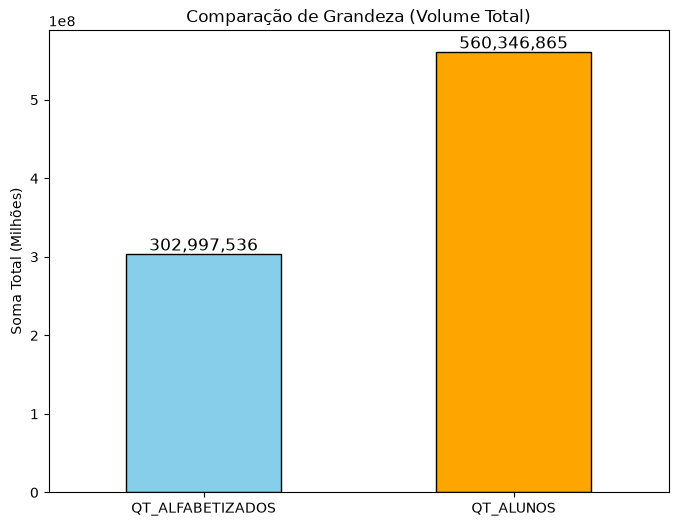

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

totais = df_meta[['QT_ALFABETIZADOS', 'QT_ALUNOS']].sum()
totais.plot.bar(color=['skyblue', 'orange'], edgecolor='black')

plt.title('Comparação de Grandeza (Volume Total)')
plt.ylabel('Soma Total (Milhões)')
plt.xticks(rotation=0) # Deixa o texto do eixo X deitado (horizontal)


for i, valor in enumerate(totais):
    plt.text(i, valor, f'{valor:,.0f}', ha='center', va='bottom', fontsize=12)

plt.show()


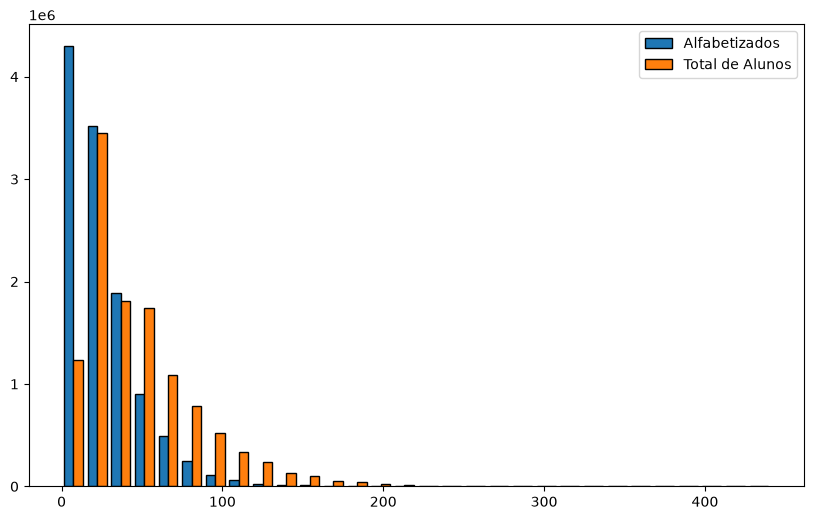

In [19]:
# Alternativa puramente com Matplotlib
plt.figure(figsize=(10, 6))

plt.hist(
    [df_meta['QT_ALFABETIZADOS'], df_meta['QT_ALUNOS']], 
    bins=30, 
    label=['Alfabetizados', 'Total de Alunos'],
    edgecolor='black'
)

plt.legend()
plt.show()


In [20]:
tabelas = ['RESULTADOS_METAS_MUNICIPIO','RESULTADOS_METAS_MUNICIPIO','RESULTADOS_METAS','TS_ALUNO','TS_ESTADO','TS_ITEM','TS_MUNICIPIO' ] 
pastas = ['dimensao','historico','fato'] 


df = carregar_parquet_s3(
    s3_client=s3,
    bucket=BUCKET,
    ano= pastas[0],
    nome_tabela=tabelas[0],
    camada="gold"
)


Lendo: s3://postech-challenge-datascience-003/gold/ano=dimensao/dados/RESULTADOS_METAS_MUNICIPIO.parquet
